## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.metrics import average_precision_score, recall_score, precision_score, precision_recall_curve, roc_auc_score, f1_score
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import shap
import graphviz
from catboost import CatBoostClassifier

from sklearn.metrics import classification_report
from skmultilearn.problem_transform import BinaryRelevance
from sklearn.preprocessing import MultiLabelBinarizer

from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier

from sklearn.multioutput import ClassifierChain
                                                        
import warnings
warnings.filterwarnings('ignore')

# pd.set_option('max_columns', None)


## Preprocessing

In [2]:
df = pd.read_csv('limited_data_v3.csv')

In [3]:
i=1

for col in df.columns:
    df.rename(columns={col: 'col_' + str(i)}, inplace=True)
    i+=1

In [4]:
df.shape[0]

1261566

In [5]:
df.isna().sum()

col_1         0
col_2         0
col_3         0
col_4         0
col_5         0
col_6         0
col_7      8657
col_8         0
col_9         1
col_10        1
col_11        0
col_12        0
col_13        0
col_14        0
col_15        0
col_16        0
col_17        0
col_18        0
col_19     8657
col_20        0
col_21        0
col_22        0
col_23        0
col_24        0
col_25        0
col_26     7708
col_27     7708
col_28        0
col_29        0
col_30        5
col_31        5
col_32        5
col_33        5
col_34        5
col_35        5
col_36        5
col_37        0
col_38    23834
col_39    23273
col_40     6504
col_41        0
col_42        0
col_43        0
col_44        0
col_45        0
col_46        0
col_47        0
col_48        0
col_49        0
col_50        0
col_51        0
col_52        0
col_53        0
dtype: int64

In [6]:
# Fillna values

df_lim = df[
            (df['col_16'] <= df['col_16'].quantile(q = 0.99)) &
            (df['col_39'] <= df['col_39'].quantile(q = 0.99)) &
            (df['col_40'] <= df['col_40'].quantile(q = 0.99)) 
]

df_lim['col_26'] = df_lim['col_26'].fillna(0)
df_lim['col_27'] = df_lim['col_27'].fillna(0)

df_lim['col_7'] = df_lim['col_7'].fillna(df_lim['col_7'] \
                                                                           .median())
df_lim['col_19'] = df_lim['col_19'].fillna(df_lim['col_19'] \
                                                                           .median())
df_lim['col_38'] = df_lim['col_38'].fillna(df_lim['col_38'] \
                                                                           .mean())
df_lim['col_39'] = df_lim['col_39'].fillna(df_lim['col_39'] \
                                                                           .median())
df_lim['col_40'] = df_lim['col_40'].fillna(df_lim['col_40'] \
                                                                           .mean())
df_lim.shape[0]


1196671

In [7]:
df_lim_ml_columns = ['col_4', 'col_5', 'col_10', 'col_11', 'col_12', 'col_13', 
                     'col_14','col_15','col_16', 'col_21', 'col_23', 'col_24',
                     'col_25','col_26','col_27', 'col_29', 'col_30', 'col_31',
                     'col_33','col_34','col_37', 'col_38', 'col_39', 'col_40',
                     'col_28']

factor_columns = ['col_43', 'col_44', 'col_45', 'col_46', 'col_47',
                  'col_48', 'col_49', 'col_51', 'col_52', 'col_53']


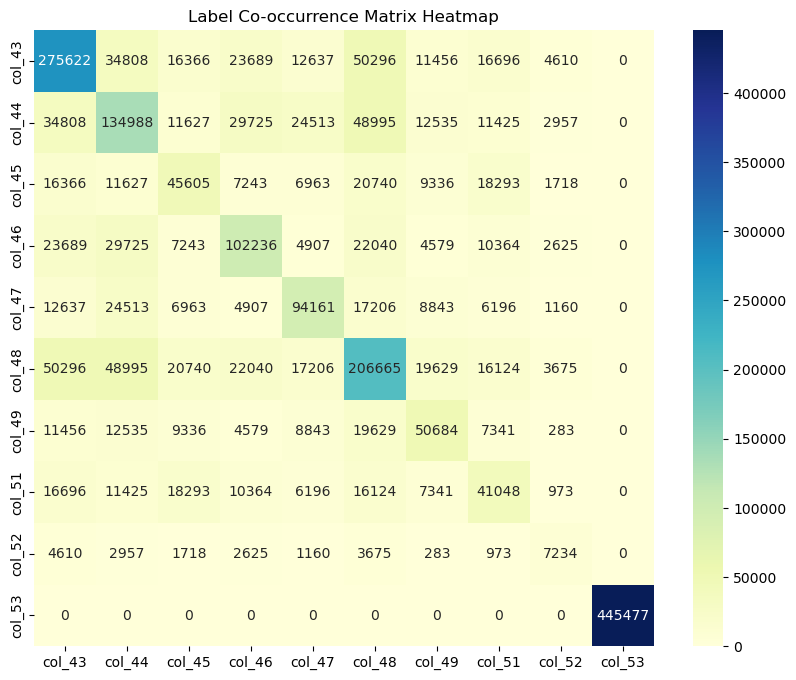

In [8]:
# Co_occurrence_matrix

co_occurrence_matrix = np.dot(df_lim[factor_columns].T, df_lim[factor_columns])

co_occurrence_df = pd.DataFrame(co_occurrence_matrix, index=factor_columns, columns=factor_columns)

co_occurrence_df

plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_df, annot=True, cmap="YlGnBu", fmt="d")
plt.title("Label Co-occurrence Matrix Heatmap")
plt.show()

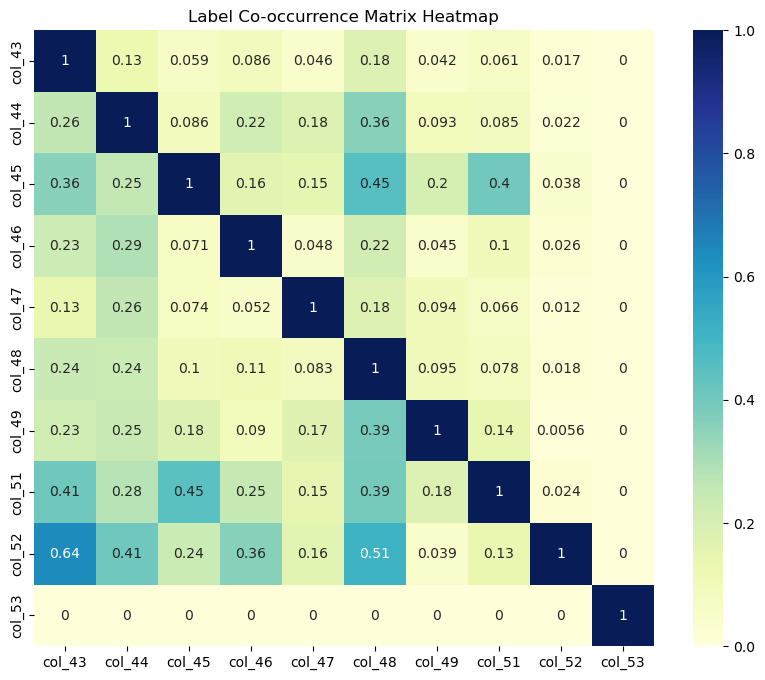

In [9]:
# Calculate the frequency of each label
frequencies = np.diag(co_occurrence_matrix)

# Conditional probability P(j | i)
weighted_co_occurrence = co_occurrence_matrix / frequencies[:, None]

# Convert to a convenient format
weighted_co_occurrence_df = pd.DataFrame(
    weighted_co_occurrence,
    index=factor_columns,
    columns=factor_columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(weighted_co_occurrence_df, annot=True, cmap="YlGnBu")
plt.title("Label Co-occurrence Matrix Heatmap")
plt.show()


When should label dependencies be taken into account?

It is important to consider label dependencies if:

Labels are strongly correlated.
For example, in medical data: if hypertension is diagnosed, there is a high probability that diabetes will also be diagnosed.

Errors caused by ignoring dependencies are critical.
For example, in recommendation systems where an accessory is recommended without the main device.

The number of labels is small (up to ~20–30).
Methods that model label dependencies become computationally expensive when the number of labels is large.

In [10]:
# Filtering for target

df_lim = df_lim[~((df_lim['col_43'] == 0) & (df_lim['col_44'] == 0) \
        & (df_lim['col_45'] == 0) & (df_lim['col_46'] == 0) & (df_lim['col_47'] == 0) \
        & (df_lim['col_48'] == 0) & (df_lim['col_49'] == 0) & (df_lim['col_51'] == 0) \
        & (df_lim['col_52'] == 0) & (df_lim['col_53'] == 0))]

df_lim = df_lim.dropna()

In [11]:
# Train/test split

X = df_lim.drop(factor_columns, axis=1)[df_lim_ml_columns]
y = df_lim[factor_columns]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=X[['col_23', 'col_25']])


## Skmultilearn

In [12]:
# Train a multi-label classification model using Binary Relevance with XGBoost and evaluate its performance

model = BinaryRelevance(
    classifier=XGBClassifier(
        use_label_encoder=False,
        eval_metric='aucpr',
        n_estimators=200,
        learning_rate=0.03,
        max_depth=9,
        min_child_weight=5,
        subsample=0.8,
        random_state=42
    )
)

model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
# MultiLabelBinarizer is used to convert the results into a convenient format
mlb = MultiLabelBinarizer(classes=factor_columns)

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=factor_columns))


Classification Report:
              precision    recall  f1-score   support

      col_43       0.53      0.00      0.00     55212
      col_44       0.58      0.05      0.08     27126
      col_45       0.00      0.00      0.00      9168
      col_46       0.00      0.00      0.00     20484
      col_47       0.00      0.00      0.00     18890
      col_48       0.51      0.02      0.04     41392
      col_49       0.50      0.00      0.00     10177
      col_51       0.00      0.00      0.00      8307
      col_52       0.00      0.00      0.00      1483
      col_53       0.62      0.31      0.41     88766

   micro avg       0.62      0.10      0.18    281005
   macro avg       0.27      0.04      0.05    281005
weighted avg       0.45      0.10      0.14    281005
 samples avg       0.13      0.13      0.13    281005



<!-- Classification Report:
                  precision    recall  f1-score   support

is_delivery_comm       0.45      0.00      0.00     39193
    is_size_comm       0.55      0.04      0.07     21140
    is_cond_comm       0.00      0.00      0.00      7065
    is_torg_comm       0.00      0.00      0.00     16336
   is_zamer_comm       0.00      0.00      0.00     15211
 is_instock_comm       0.51      0.01      0.02     32367
   is_photo_comm       0.00      0.00      0.00      7735
   is_price_comm       0.00      0.00      0.00      5650
  is_stocks_comm       0.00      0.00      0.00      1055
      is_no_comm       0.62      0.12      0.20     56815

       micro avg       0.61      0.04      0.07    202567
       macro avg       0.21      0.02      0.03    202567
    weighted avg       0.40      0.04      0.07    202567
     samples avg       0.05      0.04      0.04    202567 -->

## LGBMClassifier MultyOutput 

In [13]:
# Train a multi-label classification model using LightGBM wrapped with MultiOutputClassifier and evaluate its performance

# Create the LightGBM base model
base_model = LGBMClassifier(
    objective='binary',        # Binary classification for each label
    is_unbalance=True,         # Handle class imbalance automatically
    boosting_type='gbdt',
    learning_rate=0.01,
    n_estimators=100,
    random_state=42
    # class_weight='balanced'
)

# Wrap the base model for multi-label classification
model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = model.predict(X_test)

# Evaluate model performance
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=factor_columns))


[LightGBM] [Info] Number of positive: 220410, number of negative: 655260
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014272 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 875670, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.251704 -> initscore=-1.089543
[LightGBM] [Info] Start training from score -1.089543
[LightGBM] [Info] Number of positive: 107862, number of negative: 767808
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030860 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1318
[LightGBM] [Info] Number of data points in the train set: 875670, number of used features: 25
[LightGBM] [

## ClassifierChain

In [14]:
# Train a multi-label classification model using a Classifier Chain with XGBoost and evaluate its performance

base_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=9,
    min_child_weight=5,
    objective='binary:logistic',
    subsample=0.8,
    random_state=42
)

# Create a classifier chain to model label dependencies
chain_model = ClassifierChain(
    base_model,
    order='random',
    random_state=42
)

# Train the classifier chain
chain_model.fit(X_train, y_train)

# Generate predictions on the test set
y_pred = chain_model.predict(X_test)

# Evaluate model performance
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=factor_columns))


Classification Report:
              precision    recall  f1-score   support

      col_43       0.00      0.00      0.00     55212
      col_44       0.66      0.00      0.01     27126
      col_45       0.00      0.00      0.00      9168
      col_46       0.00      0.00      0.00     20484
      col_47       0.00      0.00      0.00     18890
      col_48       0.52      0.00      0.00     41392
      col_49       0.00      0.00      0.00     10177
      col_51       0.00      0.00      0.00      8307
      col_52       0.00      0.00      0.00      1483
      col_53       0.41      1.00      0.58     88766

   micro avg       0.41      0.32      0.36    281005
   macro avg       0.16      0.10      0.06    281005
weighted avg       0.27      0.32      0.18    281005
 samples avg       0.41      0.41      0.41    281005



## Model for items coverage

In [15]:
# Redefining the model

df_lim = df_lim[~((df_lim['col_43'] == 0) & (df_lim['col_44'] == 0) \
        & (df_lim['col_45'] == 0) & (df_lim['col_46'] == 0) & (df_lim['col_47'] == 0) \
        & (df_lim['col_48'] == 0) & (df_lim['col_49'] == 0) & (df_lim['col_51'] == 0) \
        & (df_lim['col_52'] == 0) & (df_lim['col_53'] == 0))]

df_lim = df_lim.dropna()

df_lim_ml_columns = ['col_4', 
                     'col_5', 
                     'col_10', 
                     'col_11', 
                     'col_12', 
                     'col_13', 
                     'col_7',
                     'col_19',
                     'col_14', 
                     'col_15',
                     'col_21', 
                     'col_23',
                     'col_25', 
                     'col_26',
                     'col_27',
                     'col_29', 
                     'col_30',
                     'col_31',
                     'col_33', 
                     'col_34',
                     'col_37',
                     'col_38', 
                     'col_39',
                     'col_40',
                     'col_28', 
                     'col_53']

df_lim_ml = df_lim[df_lim_ml_columns]

In [16]:
X = df_lim_ml.drop('col_53', axis=1)
y = df_lim_ml['col_53']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, 
                                                    stratify=X[['col_23', 'col_25']])


In [17]:
# Base model

CBCl = CatBoostClassifier(iterations=500, 
                        depth = 7,
                        loss_function='Logloss',
                        custom_loss= ['PRAUC', 'F1', 'Precision', 'Recall'],
                        verbose=False, 
                        class_weights = (1, 2), random_state=42)

CBCl.fit(X_train, y_train, eval_set=(X_test, y_test),
    verbose=False, plot=False
)

In [18]:
# Scores

learn_err = pd.read_csv('catboost_info/learn_error.tsv', sep='\t')
test_err = pd.read_csv('catboost_info/test_error.tsv', sep='\t')

print('Learn PRAUC: ', learn_err['PRAUC:use_weights=true'].mean(), 'Learn F1: ', learn_err['F1:use_weights=true'].mean())

print('Learn PRAUC: ', test_err['PRAUC:use_weights=true'].mean(), 'Learn F1: ', test_err['F1:use_weights=true'].mean())
    

Learn PRAUC:  0.75083870873 Learn F1:  0.7152935428414
Learn PRAUC:  0.740011171724 Learn F1:  0.7061090675620001


In [19]:
# Final Scores

test_err.mean()

iter                           249.500000
Logloss                          0.632516
PRAUC:use_weights=true           0.740011
PRAUC:use_weights=false          0.605047
F1:use_weights=true              0.706109
F1:use_weights=false             0.582752
Precision:use_weights=true       0.625223
Precision:use_weights=false      0.454797
Recall:use_weights=true          0.811390
Recall:use_weights=false         0.811390
dtype: float64

In [20]:
# Correlation with FP

y_pred = CBCl.predict(X_train)
X_train['is_fp'] = (y_pred == 1) & (y_train == 0)  # FP labels

correlation = X_train.corr()['is_fp'].sort_values(ascending=False)
print(correlation)

is_fp     1.000000
col_30    0.108616
col_21    0.087927
col_38    0.069117
col_27    0.017739
col_11    0.004992
col_31   -0.009989
col_29   -0.012950
col_23   -0.017154
col_15   -0.022353
col_34   -0.023381
col_28   -0.023693
col_25   -0.024415
col_13   -0.026581
col_33   -0.029142
col_39   -0.042993
col_26   -0.046372
col_40   -0.047459
col_37   -0.054140
col_7    -0.072823
col_19   -0.073265
col_14   -0.095663
col_10   -0.105817
col_12   -0.108656
col_5    -0.138418
col_4    -0.207233
Name: is_fp, dtype: float64


## Estimate coverage

In [21]:
## Preprocessing for eval dataset

df_val = pd.read_csv('validate.csv')

i=1

for col in df_val.columns:
    df_val.rename(columns={col: 'col_' + str(i)}, inplace=True)
    i+=1

df_val.shape[0]

10000000

In [22]:
df_val.isna().sum()

col_1          0
col_2          0
col_3          0
col_4          2
col_5          0
col_6          2
col_7          2
col_8          0
col_9          0
col_10         0
col_11         0
col_12         0
col_13         0
col_14         0
col_15         0
col_16         0
col_17         0
col_18         0
col_19         0
col_20         0
col_21         0
col_22         0
col_23         0
col_24       175
col_25       175
col_26       175
col_27       175
col_28       175
col_29       175
col_30       175
col_31         0
col_32    191855
col_33    175609
col_34    192840
dtype: int64

In [23]:
df_val_lim = df_val[
            (df_val['col_33'] <= df_val['col_33'].quantile(q = 0.99)) &
            (df_val['col_34'] <= df_val['col_34'].quantile(q = 0.99))
]

df_val_lim['col_20'] = df_val_lim['col_20'].fillna(0)
df_val_lim['col_21'] = df_val_lim['col_21'].fillna(0)

df_val_lim['col_5'] = df_val_lim['col_5'].fillna(df_val_lim['col_5'] \
                                                                           .median())
df_val_lim['col_14'] = df_val_lim['col_14'].fillna(df_val_lim['col_14'] \
                                                                           .median())
df_val_lim['col_32'] = df_val_lim['col_32'].fillna(df_val_lim['col_32'] \
                                                                           .mean())
df_val_lim['col_33'] = df_val_lim['col_33'].fillna(df_val_lim['col_33'] \
                                                                           .median())
df_val_lim['col_34'] = df_val_lim['col_34'].fillna(df_val_lim['col_34'] \
                                                                           .mean())
df_val_lim.shape[0]


9473189

In [24]:
df_val_lim_ml_columns = ['col_2', 
                         'col_3', 
                         'col_7', 
                         'col_8', 
                         'col_9', 
                         'col_10', 
                         'col_5',
                         'col_14',
                         'col_11', 
                         'col_12',
                         'col_16', 
                         'col_18',
                         'col_19', 
                         'col_20',
                         'col_21',
                         'col_23', 
                         'col_24',
                         'col_25',
                         'col_27', 
                         'col_28',
                         'col_31',
                         'col_32', 
                         'col_33',
                         'col_34',
                         'col_22']

df_val_lim_ml = df_val_lim[df_val_lim_ml_columns]

In [25]:
# Scores for predictions

# predicts = CBCl.predict_proba(df_val_lim_ml)[:,1]

# df_val_lim['prediction_mc'] = predicts

# df_val_lim[['col_1', 'prediction_mc']].to_csv('predictions.csv')